# 76 — Persistent-tracker offset diagnostics

This notebook answers one specific question: if MATLAB and Python are already very close, where does the remaining offset first appear?

The notebook runs a compact diagnostic script against the current notebook 75 outputs and saves stage-by-stage bias tables plus visual checks.

In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
OUT = ROOT / 'results' / 'notebook76_persistent_tracker_offset_diagnostics'
SCRIPT = ROOT / 'scripts' / 'diagnose_persistent_tracker_offset.py'

assert SCRIPT.exists(), SCRIPT
OUT.mkdir(parents=True, exist_ok=True)
print('Project root:', ROOT)
print('Diagnostic script:', SCRIPT)
print('Output directory:', OUT)

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Diagnostic script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/diagnose_persistent_tracker_offset.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook76_persistent_tracker_offset_diagnostics


In [2]:
env = dict(os.environ)
env.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
subprocess.run([sys.executable, str(SCRIPT)], cwd=ROOT, env=env, check=True)

# Notebook 76 — persistent-tracker offset diagnosis

Aligned 2666 MATLAB/Python samples with Python offset 1.

## Main findings

- The raw tracker offset is already present at frame 0 in the selected seed. Relative to MATLAB raw frame 0, the Python seed is +18.60 px on superficial x, -18.60 px on deep x, and -0.92 deg on angle.
- Over time, raw KLT shape is close after removing the mean bias: x_sup bias +15.97 px with demeaned RMSE 2.08 px; angle bias -1.49 deg with demeaned RMSE 0.58 deg.
- The forward x-state offset is consistent with the current Kalman x update anchoring to the initial x measurement. In a diagnostic variant that uses the current frame's x measurement instead, forward x bias drops from +18.68 px to +1.38 px.
- The angle offset changes sign at the TimTrack measurement stage: raw KLT angle bias is -1.49 deg, selected TimTrack alpha bias is +1.20 deg, and forward alpha bias is +1.01 deg.
- The final smoothed alpha remains mostly a constant offset rather than a shape mis

CompletedProcess(args=['/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/diagnose_persistent_tracker_offset.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook76_summary.md').read_text()))

stage_summary = pd.read_csv(OUT / 'stage_offset_summary.csv')
seed_frame0 = pd.read_csv(OUT / 'seed_frame0_offset.csv')
x_variant = pd.read_csv(OUT / 'x_measurement_variant_summary.csv')

display(Markdown('## Stage summary'))
display(stage_summary)

display(Markdown('## Seed vs MATLAB frame 0'))
display(seed_frame0)

display(Markdown('## Forward x diagnostic variant'))
display(x_variant)

# Notebook 76 — persistent-tracker offset diagnosis

Aligned 2666 MATLAB/Python samples with Python offset 1.

## Main findings

- The raw tracker offset is already present at frame 0 in the selected seed. Relative to MATLAB raw frame 0, the Python seed is +18.60 px on superficial x, -18.60 px on deep x, and -0.92 deg on angle.
- Over time, raw KLT shape is close after removing the mean bias: x_sup bias +15.97 px with demeaned RMSE 2.08 px; angle bias -1.49 deg with demeaned RMSE 0.58 deg.
- The forward x-state offset is consistent with the current Kalman x update anchoring to the initial x measurement. In a diagnostic variant that uses the current frame's x measurement instead, forward x bias drops from +18.68 px to +1.38 px.
- The angle offset changes sign at the TimTrack measurement stage: raw KLT angle bias is -1.49 deg, selected TimTrack alpha bias is +1.20 deg, and forward alpha bias is +1.01 deg.
- The final smoothed alpha remains mostly a constant offset rather than a shape mismatch: bias +1.03 deg, demeaned RMSE 0.54 deg.

## Interpretation

- There are two offset sources, and they happen at different stages.
- First, the autonomous seed already starts from a different fascicle segment than MATLAB, so the persistent KLT tracker inherits a near-constant spatial shift from frame 0.
- Second, the two-state Kalman x branch appears to preserve or amplify x bias because it is effectively tied to the initial x measurement, while the alpha branch inherits the positive TimTrack alpha baseline.
- That means the curves are genuinely very close in shape; the remaining difference is mostly stage-wise baseline offset, not runaway tracking error.

- Stage summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook76_persistent_tracker_offset_diagnostics/stage_offset_summary.csv`
- Seed/frame-0 CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook76_persistent_tracker_offset_diagnostics/seed_frame0_offset.csv`
- X-measurement variant CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook76_persistent_tracker_offset_diagnostics/x_measurement_variant_summary.csv`
- Difference plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook76_persistent_tracker_offset_diagnostics/offset_stage_differences.png`
- Frame-0 seed overlay: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook76_persistent_tracker_offset_diagnostics/frame0_seed_overlay.png`


## Stage summary

,stage,unit,n,bias,rmse,demeaned_rmse,first_frame_delta,median_delta,std_delta
0,seed_x_sup_vs_matlab_raw_frame0,px,1,18.600376,18.600376,0.000000,18.600376,18.600376,0.000000
1,seed_angle_vs_matlab_raw_frame0,deg,1,-0.920489,0.920489,0.000000,-0.920489,-0.920489,0.000000
2,raw_klt_x_sup_vs_matlab_raw,px,2666,15.968458,16.103270,2.079337,18.581726,15.998030,2.079337
3,raw_klt_angle_vs_matlab_raw,deg,2666,-1.488761,1.597109,0.578228,-0.921067,-1.448357,0.578228
4,selected_timtrack_alpha_vs_matlab_forward_alpha,deg,2666,1.204407,1.811885,1.353636,2.479511,1.106036,1.353636
5,raw_timtrack_alpha_vs_matlab_forward_alpha,deg,2666,1.161834,1.906103,1.511083,2.479511,1.102814,1.511083
6,predicted_segment_angle_vs_matlab_forward_alpha,deg,2666,1.006580,1.218809,0.687236,-0.921067,1.026315,0.687236
7,forward_state_x_vs_matlab_forward_x,px,2666,18.676630,18.750015,1.657272,18.581726,18.938311,1.657272
8,forward_state_alpha_vs_matlab_forward_alpha,deg,2666,1.006874,1.217969,0.685312,-0.921067,1.022243,0.685312
9,smoothed_state_alpha_vs_matlab_final_alpha,deg,2666,1.034021,1.166109,0.539085,-0.921067,1.052802,0.539085


## Seed vs MATLAB frame 0

,quantity,matlab,python,delta_python_minus_matlab
0,x_sup_px,733.000000,751.600376,18.600376
1,y_sup_px,54.418755,55.872882,1.454127
2,x_deep_px,-27.000000,-45.600364,-18.600364
3,y_deep_px,309.013432,308.759853,-0.253579
4,angle_deg,18.520489,17.600000,-0.920489
5,length_px,801.510106,836.349711,34.839606
6,seed_alpha_deg,18.520489,17.600000,-0.920489


## Forward x diagnostic variant

,mode,n,bias,rmse,demeaned_rmse,first_frame_delta,median_delta,std_delta
0,current_initial_x_measurement,2666,18.676630,18.750015,1.657272,18.581726,18.938311,1.657272
1,diagnostic_per_frame_x_measurement,2666,1.380744,6.129492,5.971952,18.581726,2.238624,5.971952


## Frame-0 seed overlay

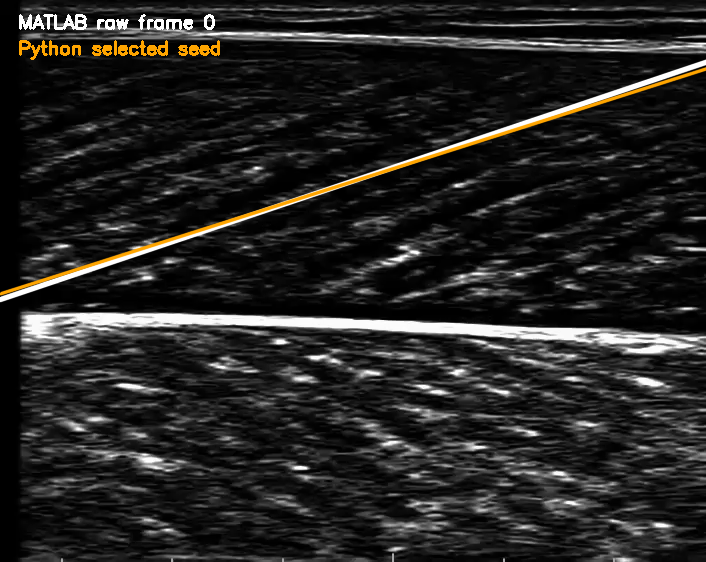

## Stage-wise offset traces

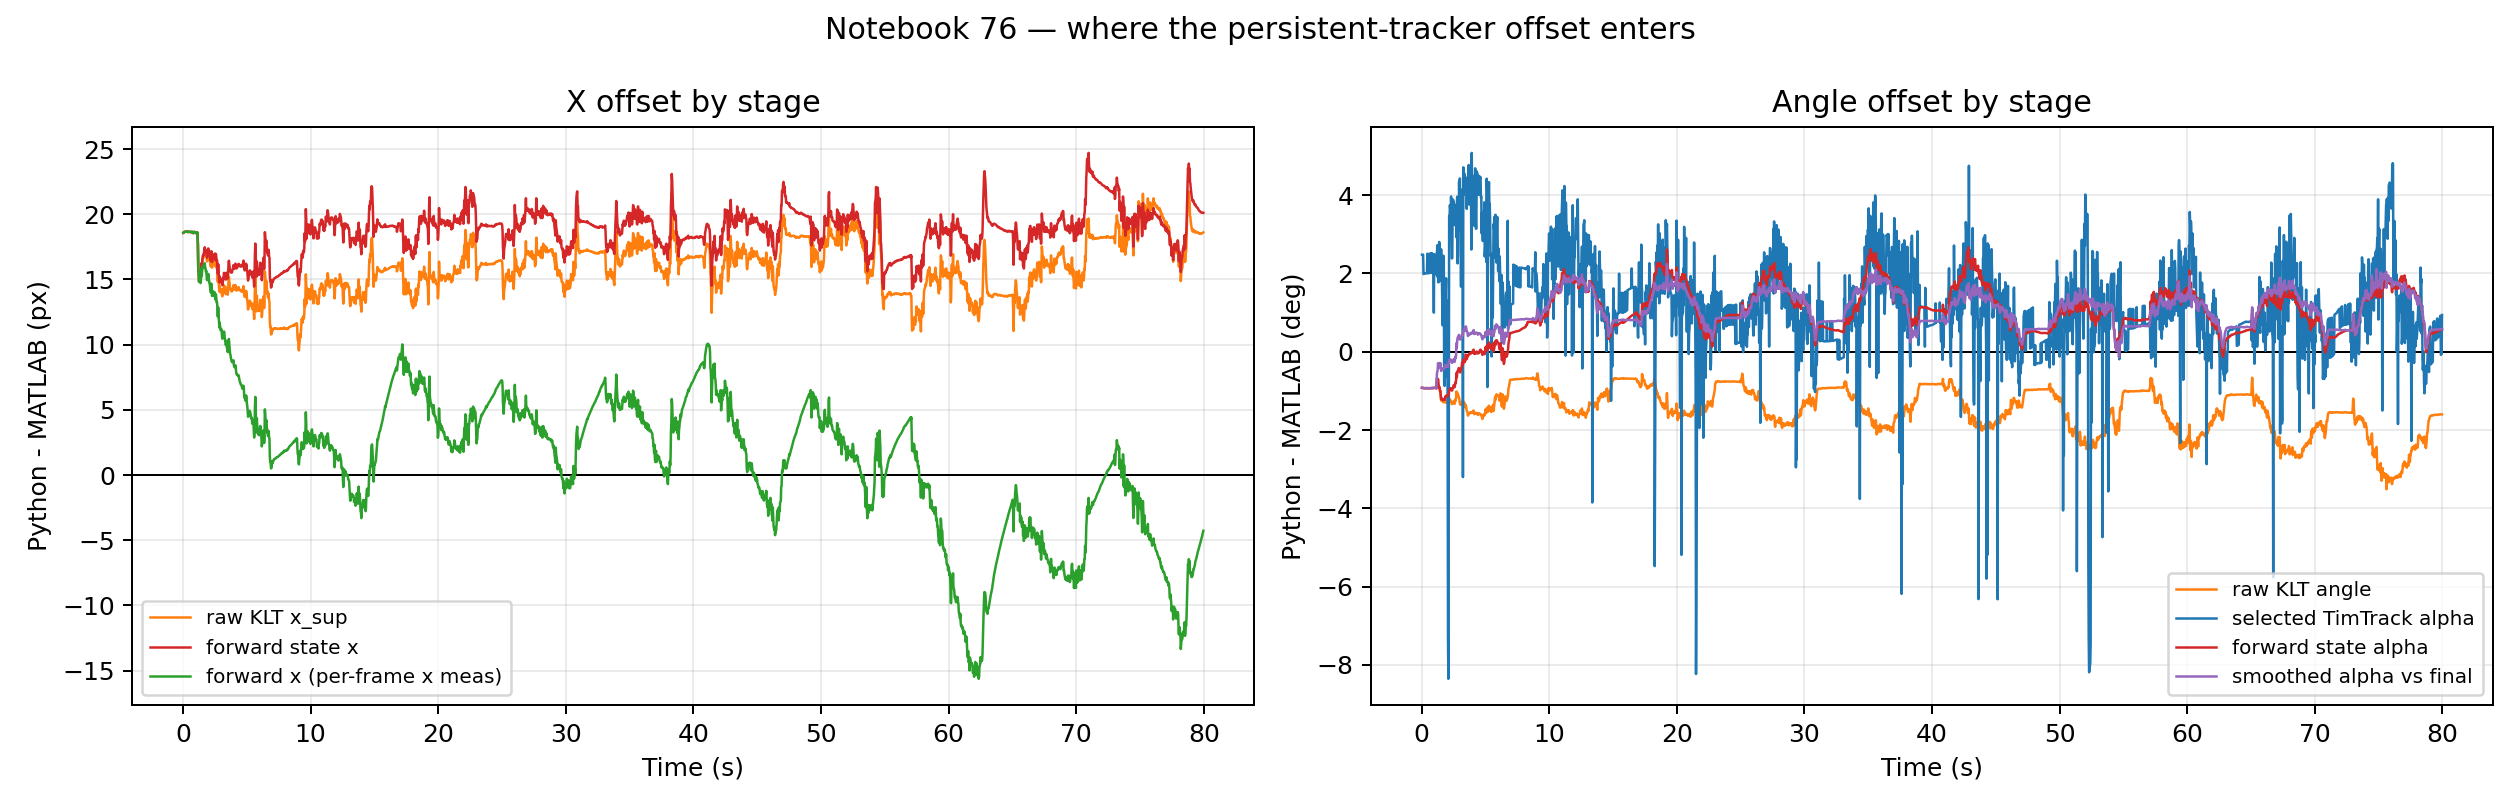

In [4]:
display(Markdown('## Frame-0 seed overlay'))
display(Image(filename=str(OUT / 'frame0_seed_overlay.png')))

display(Markdown('## Stage-wise offset traces'))
display(Image(filename=str(OUT / 'offset_stage_differences.png')))